In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [4]:


import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import confusion_matrix, classification_report

In [5]:


DATASET_DIR = "/kaggle/input/datasets/gunavenkatdoddi/eye-diseases-classification/dataset"
IMG_SIZE = (300, 300)
BATCH_SIZE = 32
EPOCHS = 25
AUTOTUNE = tf.data.AUTOTUNE

print("GPU:", tf.config.list_physical_devices('GPU'))

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [6]:


class_counts = {}
total_images = 0

for class_name in os.listdir(DATASET_DIR):
    class_path = os.path.join(DATASET_DIR, class_name)
    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        class_counts[class_name] = count
        total_images += count

print("📊 Total Images:", total_images)
print("📊 Total Classes:", len(class_counts))

for k, v in class_counts.items():
    print(f"{k} : {v}")

📊 Total Images: 4217
📊 Total Classes: 4
glaucoma : 1007
normal : 1074
diabetic_retinopathy : 1098
cataract : 1038


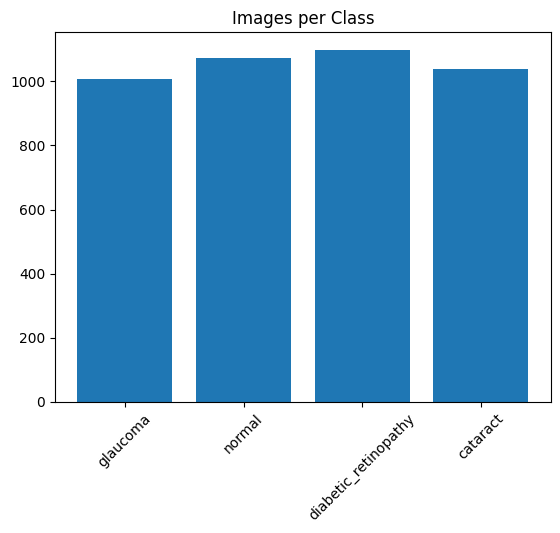

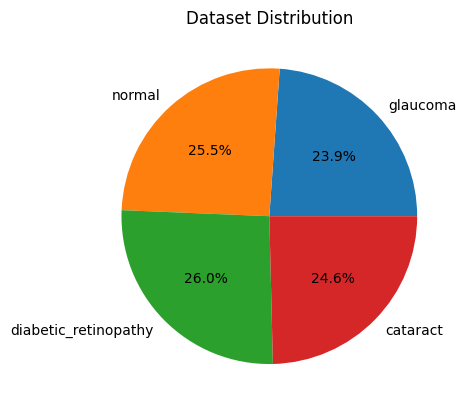

In [7]:
# Bar Graph
plt.figure()
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45)
plt.title("Images per Class")
plt.show()

# Pie Chart
plt.figure()
plt.pie(class_counts.values(), labels=class_counts.keys(), autopct='%1.1f%%')
plt.title("Dataset Distribution")
plt.show()

In [8]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

Found 4217 files belonging to 4 classes.
Using 3374 files for training.


I0000 00:00:1776824507.725338      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776824507.731376      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 4217 files belonging to 4 classes.
Using 843 files for validation.


In [9]:
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

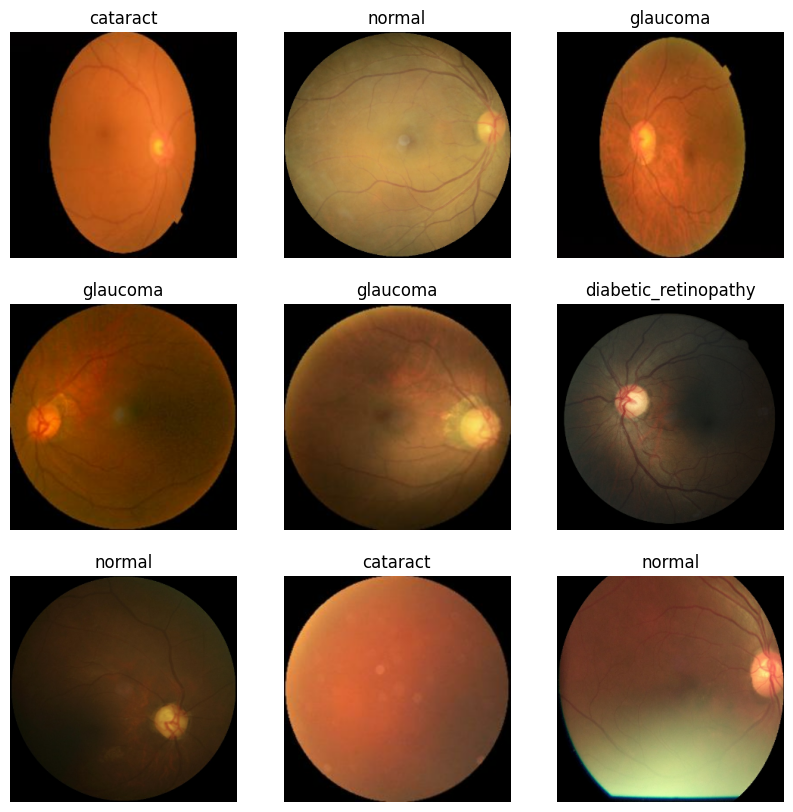

In [10]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [11]:
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

In [12]:
base_model = tf.keras.applications.EfficientNetB3(
    include_top=False,
    weights='imagenet',
    input_shape=(300, 300, 3)
)

for layer in base_model.layers[:-40]:
    layer.trainable = False

preprocess = tf.keras.applications.efficientnet.preprocess_input

inputs = tf.keras.Input(shape=(300, 300, 3))
x = data_aug(inputs)
x = preprocess(x)
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.6)(x)

outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs, outputs)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,184,179 (42.66 MB)

 Trainable params: 4,761,016 (18.16 MB)

 Non-trainable params: 6,423,163 (24.50 MB)

In [14]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
cb = [
    callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.3),
    callbacks.ModelCheckpoint("best_model.keras", save_best_only=True)
]

In [16]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=cb
)

Epoch 1/25


E0000 00:00:1776824595.374932      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb3_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1776824599.554888     172 cuda_dnn.cc:529] Loaded cuDNN version 91002


106/106 ━━━━━━━━━━━━━━━━━━━━ 74s 440ms/step - accuracy: 0.5205 - loss: 1.4427 - val_accuracy: 0.7248 - val_loss: 0.7312 - learning_rate: 1.0000e-04
Epoch 2/25
106/106 ━━━━━━━━━━━━━━━━━━━━ 39s 368ms/step - accuracy: 0.7492 - loss: 0.6870 - val_accuracy: 0.7805 - val_loss: 0.5533 - learning_rate: 1.0000e-04
Epoch 3/25
106/106 ━━━━━━━━━━━━━━━━━━━━ 41s 385ms/step - accuracy: 0.7938 - loss: 0.5969 - val_accuracy: 0.7948 - val_loss: 0.5275 - learning_rate: 1.0000e-04
Epoch 4/25
106/106 ━━━━━━━━━━━━━━━━━━━━ 40s 378ms/step - accuracy: 0.8325 - loss: 0.4593 - val_accuracy: 0.8446 - val_loss: 0.4556 - learning_rate: 1.0000e-04
Epoch 5/25
106/106 ━━━━━━━━━━━━━━━━━━━━ 39s 366ms/step - accuracy: 0.8511 - loss: 0.4053 - val_accuracy: 0.8458 - val_loss: 0.4707 - learning_rate: 1.0000e-04
Epoch 6/25
106/106 ━━━━━━━━━━━━━━━━━━━━ 39s 367ms/step - accuracy: 0.8460 - loss: 0.4091 - val_accuracy: 0.8280 - val_loss: 0.5318 - learning_rate: 1.0000e-04
Epoch 7/25
106/106 ━━━━━━━━━━━━━━━━━━━━ 40s 379ms/step - 

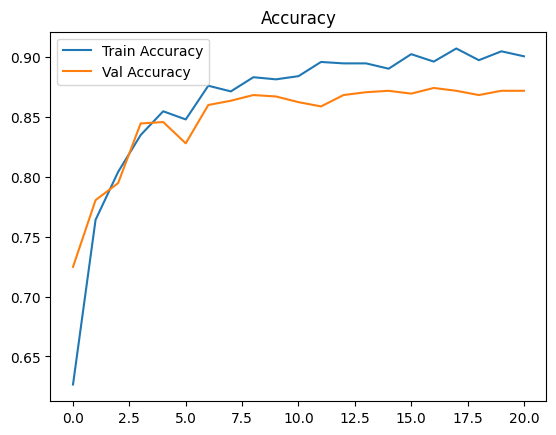

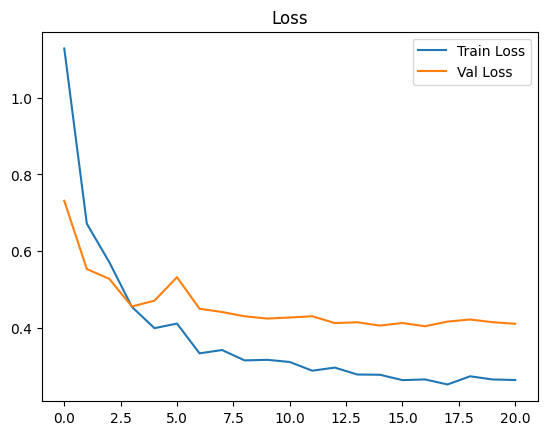

In [17]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure()
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.figure()
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.legend()
plt.title("Loss")
plt.show()

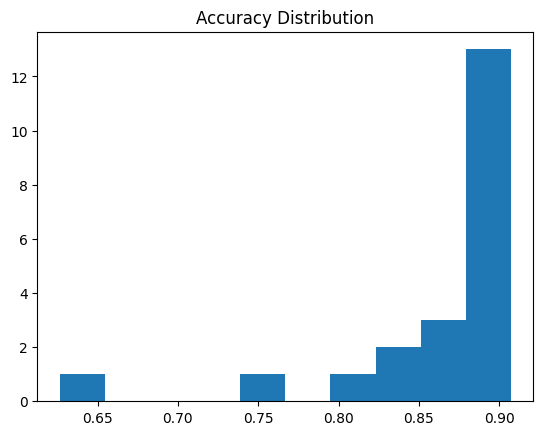

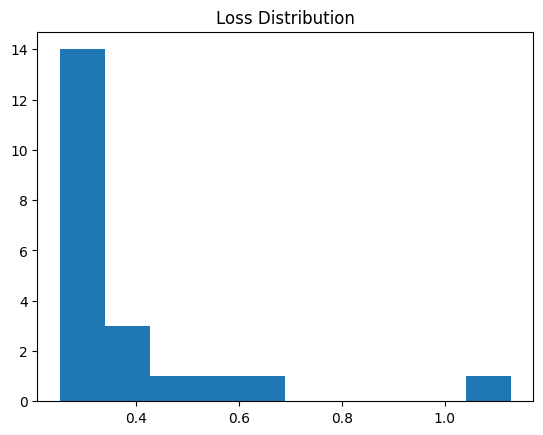

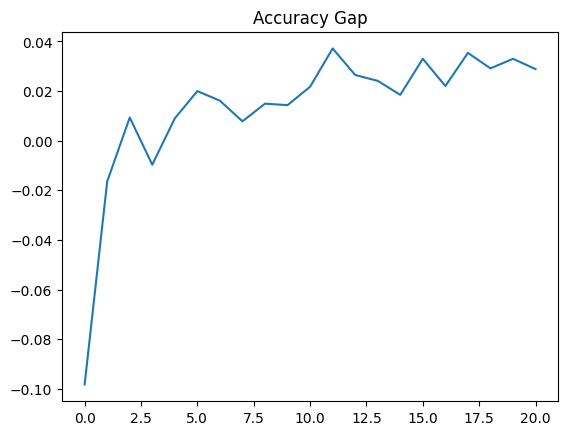

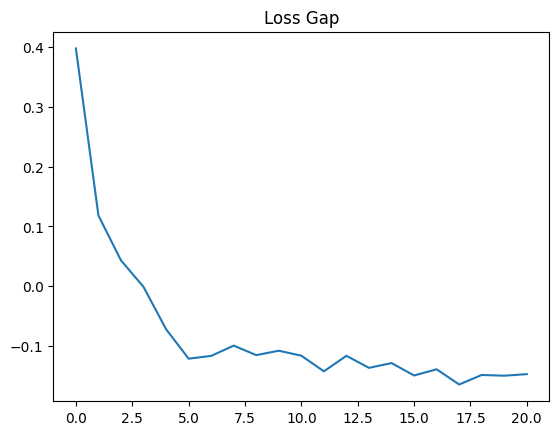

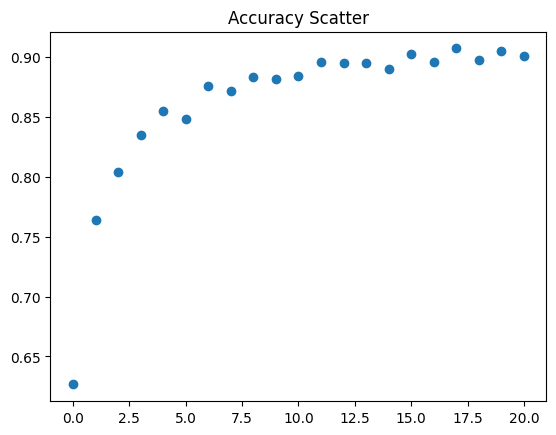

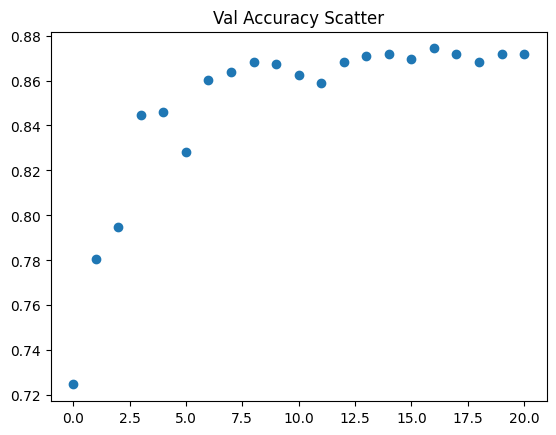

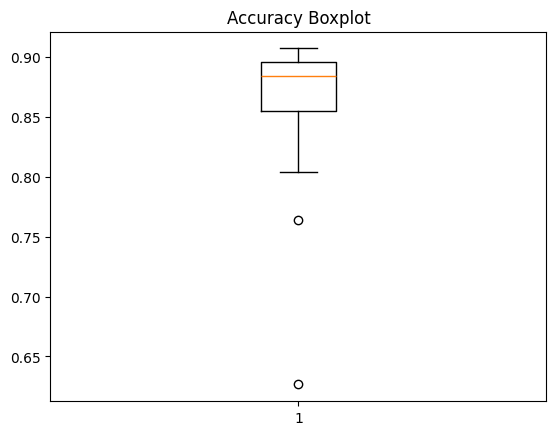

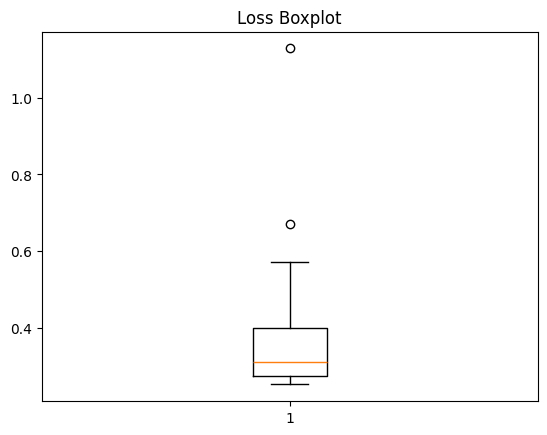

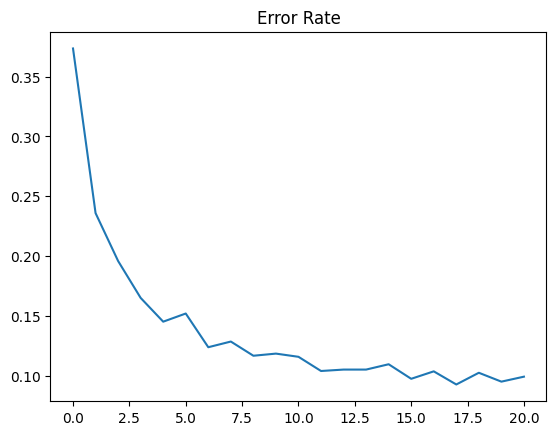

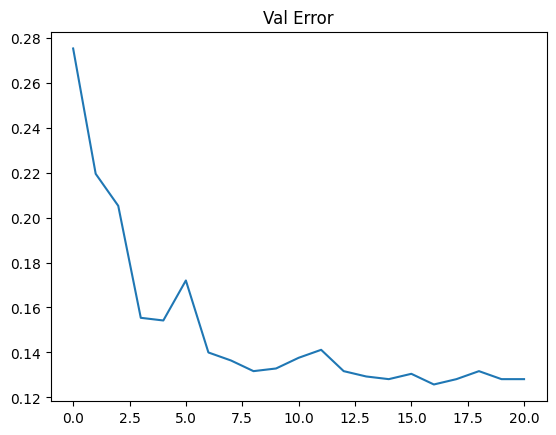

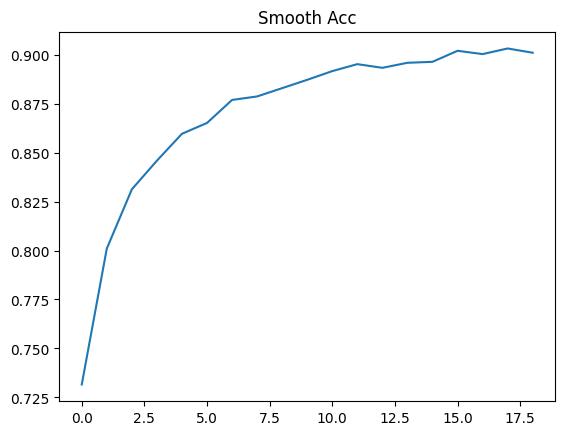

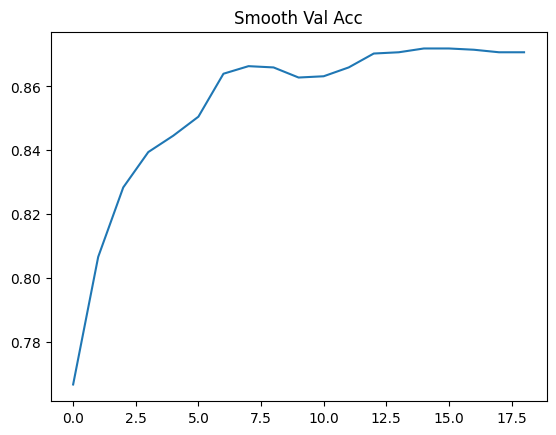

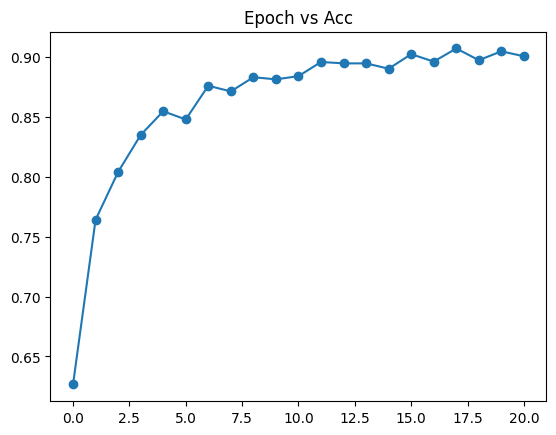

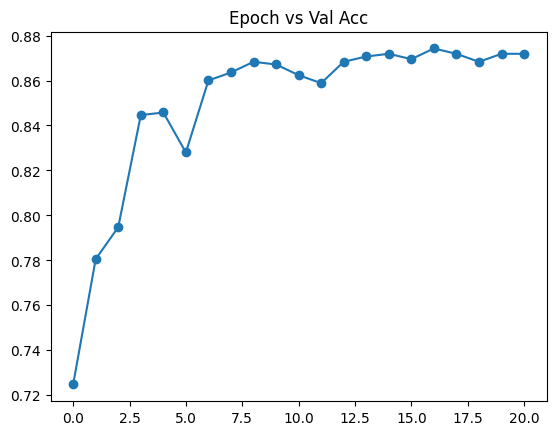

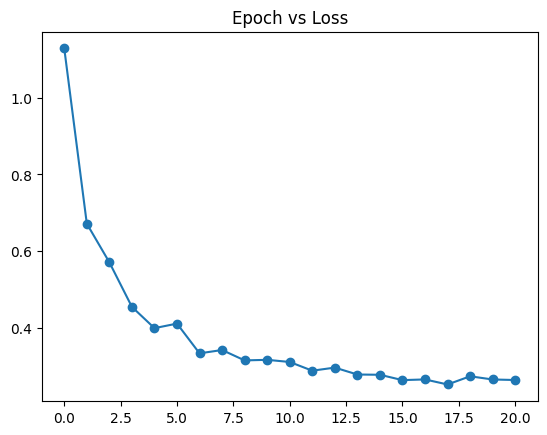

In [18]:
plt.figure(); plt.hist(acc); plt.title("Accuracy Distribution"); plt.show()
plt.figure(); plt.hist(loss); plt.title("Loss Distribution"); plt.show()
plt.figure(); plt.plot(np.array(acc)-np.array(val_acc)); plt.title("Accuracy Gap"); plt.show()
plt.figure(); plt.plot(np.array(loss)-np.array(val_loss)); plt.title("Loss Gap"); plt.show()
plt.figure(); plt.scatter(range(len(acc)), acc); plt.title("Accuracy Scatter"); plt.show()
plt.figure(); plt.scatter(range(len(val_acc)), val_acc); plt.title("Val Accuracy Scatter"); plt.show()
plt.figure(); plt.boxplot(acc); plt.title("Accuracy Boxplot"); plt.show()
plt.figure(); plt.boxplot(loss); plt.title("Loss Boxplot"); plt.show()
plt.figure(); plt.plot(1-np.array(acc)); plt.title("Error Rate"); plt.show()
plt.figure(); plt.plot(1-np.array(val_acc)); plt.title("Val Error"); plt.show()
plt.figure(); plt.plot(np.convolve(acc, np.ones(3)/3, mode='valid')); plt.title("Smooth Acc"); plt.show()
plt.figure(); plt.plot(np.convolve(val_acc, np.ones(3)/3, mode='valid')); plt.title("Smooth Val Acc"); plt.show()
plt.figure(); plt.plot(acc, 'o-'); plt.title("Epoch vs Acc"); plt.show()
plt.figure(); plt.plot(val_acc, 'o-'); plt.title("Epoch vs Val Acc"); plt.show()
plt.figure(); plt.plot(loss, 'o-'); plt.title("Epoch vs Loss"); plt.show()

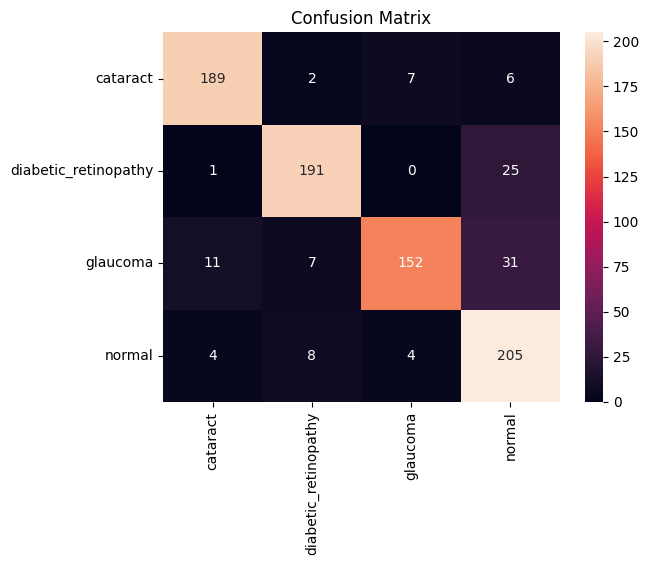

In [19]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Confusion Matrix")
plt.show()

In [20]:
print(classification_report(y_true, y_pred, target_names=class_names))

                      precision    recall  f1-score   support

            cataract       0.92      0.93      0.92       204
diabetic_retinopathy       0.92      0.88      0.90       217
            glaucoma       0.93      0.76      0.84       201
              normal       0.77      0.93      0.84       221

            accuracy                           0.87       843
           macro avg       0.89      0.87      0.87       843
        weighted avg       0.88      0.87      0.87       843



In [21]:
model.save("final_eye_model.keras")
model.save("final_eye_model.h5")

print("Model Saved Successfully")

Model Saved Successfully


I0000 00:00:1776877751.178862     128 cuda_dnn.cc:529] Loaded cuDNN version 91002


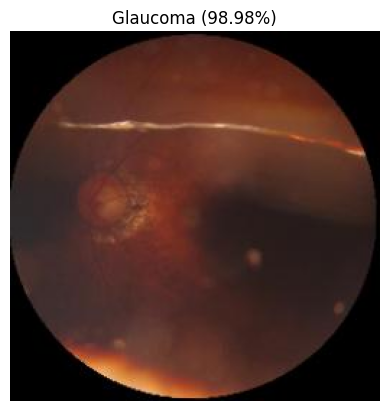

Prediction: Glaucoma
Confidence: 98.98274 %


In [6]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from IPython.display import Image, display

# Load model (use your correct path)
model_path = "/kaggle/input/models/abhaypatil23/eye/other/default/1/final_eye_model.keras"
model = tf.keras.models.load_model(model_path)

class_names = ["Cataract", "Diabetic Retinopathy", "Glaucoma", "Normal"]

# 👇 Upload manually in Kaggle (left panel → upload file)
IMAGE_PATH = "/kaggle/input/datasets/abhaypatil23/test-demo/_9_9966988.jpg"   # change file name

# Read image
img = cv2.imread(IMAGE_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (300, 300))
img_array = np.expand_dims(img_resized, axis=0)
img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)

# Predict
pred = model.predict(img_array, verbose=0)
pred_class = class_names[np.argmax(pred)]
confidence = np.max(pred)

# Show result
plt.imshow(img_rgb)
plt.title(f"{pred_class} ({confidence*100:.2f}%)")
plt.axis("off")
plt.show()

print("Prediction:", pred_class)
print("Confidence:", confidence*100, "%")

Found 4217 files belonging to 4 classes.
Using 3374 files for training.
Found 4217 files belonging to 4 classes.
Using 843 files for validation.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/tmp/ipykernel_55/4289830595.py:114: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_mob = tf.keras.applications.MobileNetV2(


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

🚀 Training EfficientNetB3

Epoch 1/20


E0000 00:00:1777095880.480863      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_5_1/efficientnetb3_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


106/106 ━━━━━━━━━━━━━━━━━━━━ 71s 415ms/step - accuracy: 0.6332 - loss: 1.1767 - val_accuracy: 0.8422 - val_loss: 0.4805 - learning_rate: 3.0000e-04
Epoch 2/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 37s 349ms/step - accuracy: 0.8299 - loss: 0.4906 - val_accuracy: 0.8363 - val_loss: 0.3881 - learning_rate: 3.0000e-04
Epoch 3/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 37s 352ms/step - accuracy: 0.8635 - loss: 0.3758 - val_accuracy: 0.8766 - val_loss: 0.3049 - learning_rate: 3.0000e-04
Epoch 4/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 37s 350ms/step - accuracy: 0.8893 - loss: 0.3059 - val_accuracy: 0.8754 - val_loss: 0.3748 - learning_rate: 3.0000e-04
Epoch 5/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 37s 348ms/step - accuracy: 0.9052 - loss: 0.2829 - val_accuracy: 0.9027 - val_loss: 0.3055 - learning_rate: 3.0000e-04
Epoch 6/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 37s 350ms/step - accuracy: 0.9114 - loss: 0.2276 - val_accuracy: 0.8790 - val_loss: 0.3812 - learning_rate: 3.0000e-04
Epoch 7/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 37s 352ms/step - 

...

106/106 ━━━━━━━━━━━━━━━━━━━━ 39s 224ms/step - accuracy: 0.6360 - loss: 1.1406 - val_accuracy: 0.8078 - val_loss: 0.5877 - learning_rate: 3.0000e-04
Epoch 2/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 21s 194ms/step - accuracy: 0.8519 - loss: 0.4491 - val_accuracy: 0.9146 - val_loss: 0.2743 - learning_rate: 3.0000e-04
Epoch 3/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 20s 188ms/step - accuracy: 0.8892 - loss: 0.3276 - val_accuracy: 0.8956 - val_loss: 0.2745 - learning_rate: 3.0000e-04
Epoch 4/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 20s 186ms/step - accuracy: 0.8914 - loss: 0.2948 - val_accuracy: 0.8505 - val_loss: 0.4236 - learning_rate: 3.0000e-04
Epoch 5/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 20s 186ms/step - accuracy: 0.8918 - loss: 0.3178 - val_accuracy: 0.9063 - val_loss: 0.2768 - learning_rate: 3.0000e-04
Epoch 6/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 20s 189ms/step - accuracy: 0.9273 - loss: 0.2039 - val_accuracy: 0.9122 - val_loss: 0.2511 - learning_rate: 9.0000e-05
Epoch 7/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 20s 189ms/step - 


🚀 Training MobileNetV2

Epoch 1/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 26s 161ms/step - accuracy: 0.5966 - loss: 1.3574 - val_accuracy: 0.6441 - val_loss: 0.9479 - learning_rate: 3.0000e-04
Epoch 2/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 15s 144ms/step - accuracy: 0.7494 - loss: 0.7743 - val_accuracy: 0.6346 - val_loss: 1.0966 - learning_rate: 3.0000e-04
Epoch 3/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 15s 144ms/step - accuracy: 0.7889 - loss: 0.5980 - val_accuracy: 0.6726 - val_loss: 1.0768 - learning_rate: 3.0000e-04
Epoch 4/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 15s 142ms/step - accuracy: 0.8086 - loss: 0.5020 - val_accuracy: 0.6335 - val_loss: 1.5061 - learning_rate: 3.0000e-04
Epoch 5/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 15s 141ms/step - accuracy: 0.8230 - loss: 0.4804 - val_accuracy: 0.6524 - val_loss: 1.4947 - learning_rate: 9.0000e-05
Epoch 6/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 15s 142ms/step - accuracy: 0.8316 - loss: 0.4116 - val_accuracy: 0.7023 - val_loss: 1.3087 - learning_rate: 9.0000e-05
27/27 ━━━━━━━━━━━━━━━


🚀 Training ResNet50

Epoch 1/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 67s 475ms/step - accuracy: 0.7011 - loss: 1.1074 - val_accuracy: 0.8327 - val_loss: 1.0923 - learning_rate: 3.0000e-04
Epoch 2/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 44s 416ms/step - accuracy: 0.8507 - loss: 0.4354 - val_accuracy: 0.8754 - val_loss: 0.9022 - learning_rate: 3.0000e-04
Epoch 3/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 45s 420ms/step - accuracy: 0.8905 - loss: 0.3469 - val_accuracy: 0.8814 - val_loss: 0.4388 - learning_rate: 3.0000e-04
Epoch 4/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 45s 420ms/step - accuracy: 0.9023 - loss: 0.2752 - val_accuracy: 0.8588 - val_loss: 0.4714 - learning_rate: 3.0000e-04
Epoch 5/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 44s 416ms/step - accuracy: 0.9134 - loss: 0.2882 - val_accuracy: 0.3345 - val_loss: 110.1897 - learning_rate: 3.0000e-04
Epoch 6/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 44s 420ms/step - accuracy: 0.9065 - loss: 0.3540 - val_accuracy: 0.8921 - val_loss: 0.6221 - learning_rate: 3.0000e-04
Epoch 7/20
106/106 ━━━


🚀 Training DenseNet121

Epoch 1/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 61s 392ms/step - accuracy: 0.4586 - loss: 1.4020 - val_accuracy: 0.6145 - val_loss: 0.9873 - learning_rate: 3.0000e-04
Epoch 2/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 33s 312ms/step - accuracy: 0.7056 - loss: 0.7911 - val_accuracy: 0.6951 - val_loss: 0.7814 - learning_rate: 3.0000e-04
Epoch 3/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 33s 310ms/step - accuracy: 0.7728 - loss: 0.5850 - val_accuracy: 0.7153 - val_loss: 0.7966 - learning_rate: 3.0000e-04
Epoch 4/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 33s 315ms/step - accuracy: 0.7957 - loss: 0.5231 - val_accuracy: 0.8066 - val_loss: 0.5467 - learning_rate: 3.0000e-04
Epoch 5/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 33s 314ms/step - accuracy: 0.8048 - loss: 0.4905 - val_accuracy: 0.8244 - val_loss: 0.5150 - learning_rate: 3.0000e-04
Epoch 6/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 33s 311ms/step - accuracy: 0.8423 - loss: 0.4055 - val_accuracy: 0.7758 - val_loss: 0.6816 - learning_rate: 3.0000e-04
Epoch 7/20
106/106 ━━


📊 Model Comparison:
             Model  Accuracy
0  EfficientNetB3  0.911032
1  EfficientNetB0  0.925267
2     MobileNetV2  0.644128
3        ResNet50  0.916963
4     DenseNet121  0.874259


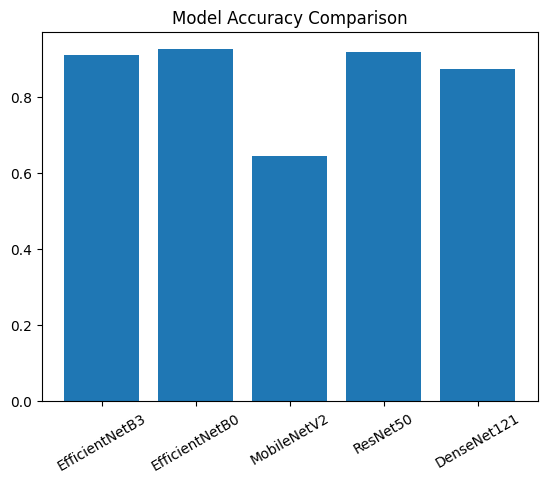

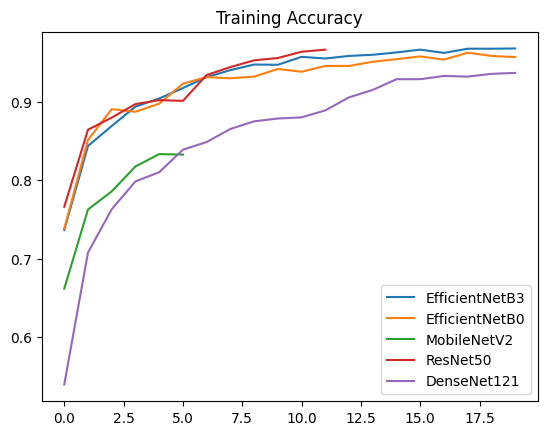

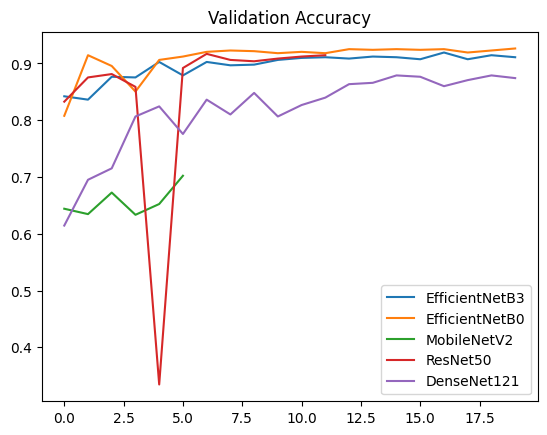

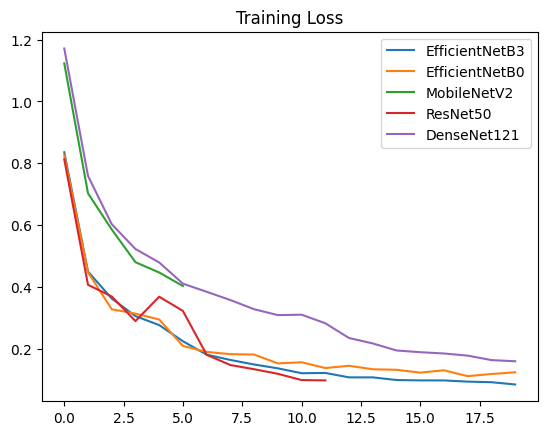

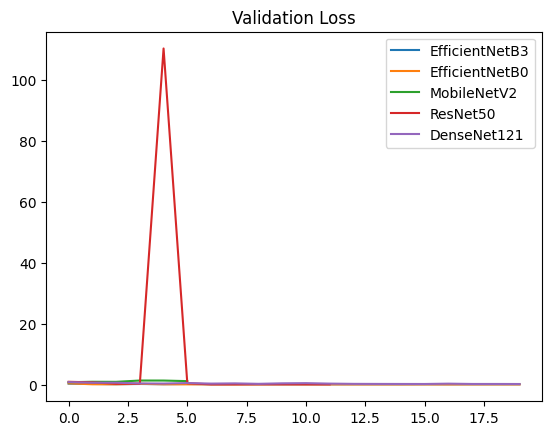


🏆 Best Model: EfficientNetB0
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/ste

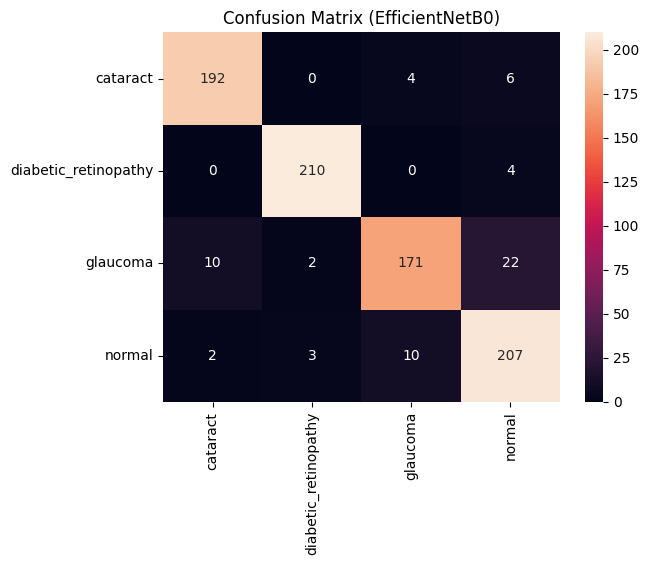


📄 Classification Report:

                      precision    recall  f1-score   support

            cataract       0.94      0.95      0.95       202
diabetic_retinopathy       0.98      0.98      0.98       214
            glaucoma       0.92      0.83      0.88       205
              normal       0.87      0.93      0.90       222

            accuracy                           0.93       843
           macro avg       0.93      0.92      0.92       843
        weighted avg       0.93      0.93      0.92       843



In [3]:
# ===============================
# IMPORTS
# ===============================
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd

from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import confusion_matrix, classification_report

# ===============================
# CONFIG
# ===============================
DATASET_DIR = "/kaggle/input/datasets/gunavenkatdoddi/eye-diseases-classification/dataset"
IMG_SIZE = (300, 300)   # same as your original EfficientNet
BATCH_SIZE = 32
EPOCHS = 20
AUTOTUNE = tf.data.AUTOTUNE

# ===============================
# LOAD DATA
# ===============================
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

# ===============================
# DATA AUGMENTATION
# ===============================
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# ===============================
# CALLBACKS
# ===============================
cb = [
    callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(factor=0.3, patience=3, min_lr=1e-6)
]

# ===============================
# COMMON HEAD (YOUR STYLE)
# ===============================
def add_custom_head(base_model):
    inputs = tf.keras.Input(shape=(300,300,3))
    x = data_aug(inputs)
    x = tf.keras.applications.efficientnet.preprocess_input(x)

    x = base_model(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.6)(x)

    outputs = layers.Dense(len(class_names), activation='softmax')(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ===============================
# MODELS (ALL USING YOUR STYLE)
# ===============================
models_dict = {}

# EfficientNetB3 (YOUR MAIN)
base_eff = tf.keras.applications.EfficientNetB3(
    include_top=False, weights='imagenet', input_shape=(300,300,3)
)
for layer in base_eff.layers[:-40]:
    layer.trainable = False
models_dict["EfficientNetB3"] = add_custom_head(base_eff)

# EfficientNetB0 (lighter version)
base_eff0 = tf.keras.applications.EfficientNetB0(
    include_top=False, weights='imagenet', input_shape=(300,300,3)
)
for layer in base_eff0.layers[:-40]:
    layer.trainable = False
models_dict["EfficientNetB0"] = add_custom_head(base_eff0)

# MobileNetV2
base_mob = tf.keras.applications.MobileNetV2(
    include_top=False, weights='imagenet', input_shape=(300,300,3)
)
for layer in base_mob.layers[:-30]:
    layer.trainable = False
models_dict["MobileNetV2"] = add_custom_head(base_mob)

# ResNet50
base_res = tf.keras.applications.ResNet50(
    include_top=False, weights='imagenet', input_shape=(300,300,3)
)
for layer in base_res.layers[:-40]:
    layer.trainable = False
models_dict["ResNet50"] = add_custom_head(base_res)

# DenseNet121 (NEW MODEL 🔥)
base_dense = tf.keras.applications.DenseNet121(
    include_top=False, weights='imagenet', input_shape=(300,300,3)
)
for layer in base_dense.layers[:-40]:
    layer.trainable = False
models_dict["DenseNet121"] = add_custom_head(base_dense)

# ===============================
# TRAIN ALL MODELS
# ===============================
history_dict = {}
results = {}

for name, model in models_dict.items():
    print(f"\n🚀 Training {name}\n")

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=cb,
        verbose=1
    )

    history_dict[name] = history.history

    loss, acc = model.evaluate(val_ds)
    results[name] = acc

    model.save(f"{name}_model.h5")

# ===============================
# COMPARISON TABLE
# ===============================
df = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": list(results.values())
})

print("\n📊 Model Comparison:\n", df)

# ===============================
# GRAPH 1: ACCURACY BAR
# ===============================
plt.figure()
plt.bar(df["Model"], df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=30)
plt.show()

# ===============================
# GRAPH 2: TRAIN ACCURACY
# ===============================
plt.figure()
for name in history_dict:
    plt.plot(history_dict[name]['accuracy'], label=name)
plt.title("Training Accuracy")
plt.legend()
plt.show()

# ===============================
# GRAPH 3: VALIDATION ACCURACY
# ===============================
plt.figure()
for name in history_dict:
    plt.plot(history_dict[name]['val_accuracy'], label=name)
plt.title("Validation Accuracy")
plt.legend()
plt.show()

# ===============================
# GRAPH 4: TRAIN LOSS
# ===============================
plt.figure()
for name in history_dict:
    plt.plot(history_dict[name]['loss'], label=name)
plt.title("Training Loss")
plt.legend()
plt.show()

# ===============================
# GRAPH 5: VALIDATION LOSS
# ===============================
plt.figure()
for name in history_dict:
    plt.plot(history_dict[name]['val_loss'], label=name)
plt.title("Validation Loss")
plt.legend()
plt.show()

# ===============================
# BEST MODEL
# ===============================
best_model_name = max(results, key=results.get)
best_model = models_dict[best_model_name]

print("\n🏆 Best Model:", best_model_name)

y_true, y_pred = [], []

for images, labels in val_ds:
    preds = best_model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title(f"Confusion Matrix ({best_model_name})")
plt.show()

print("\n📄 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

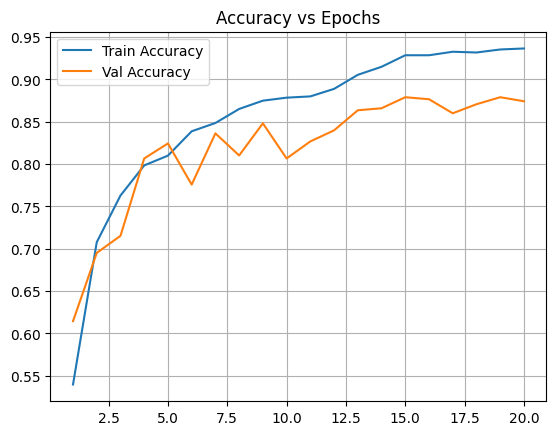

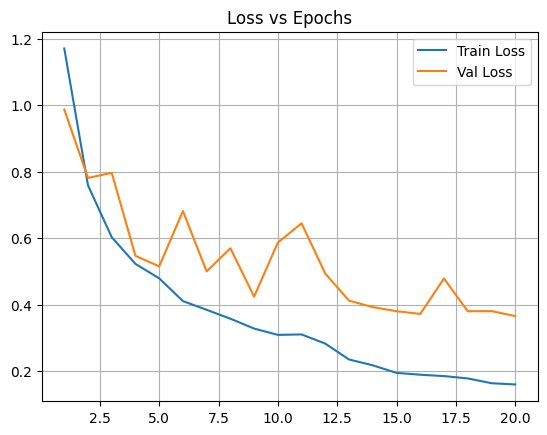

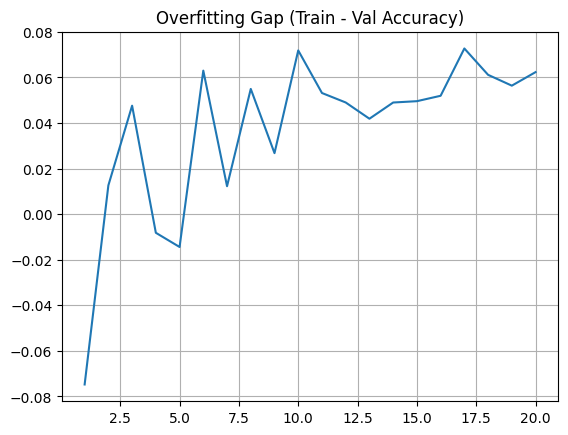

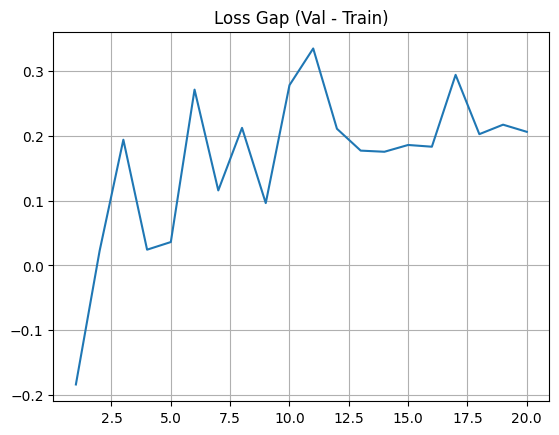

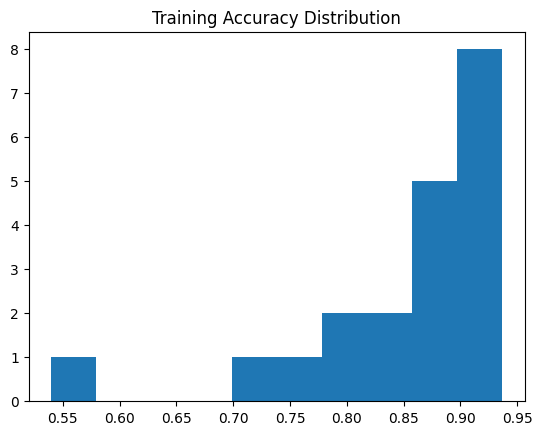

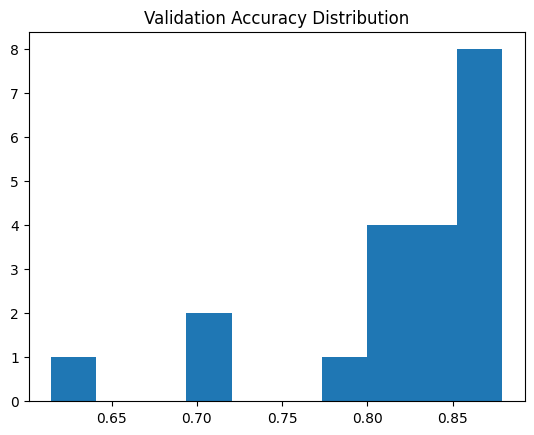

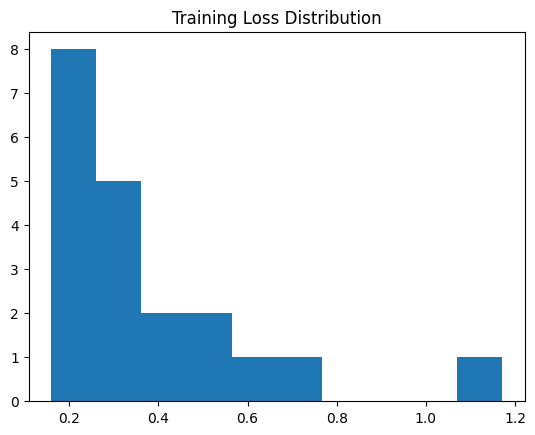

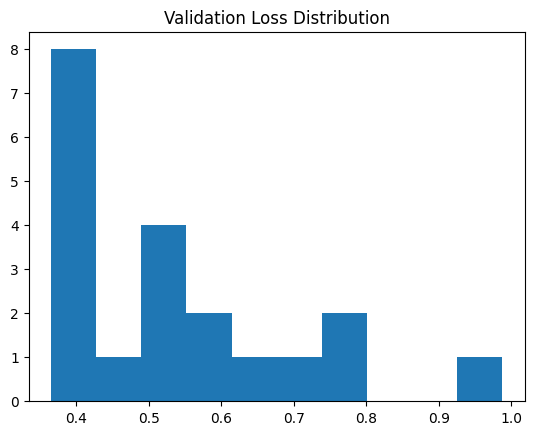

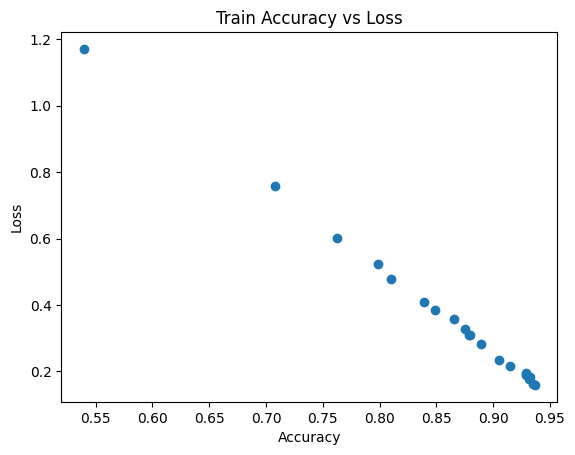

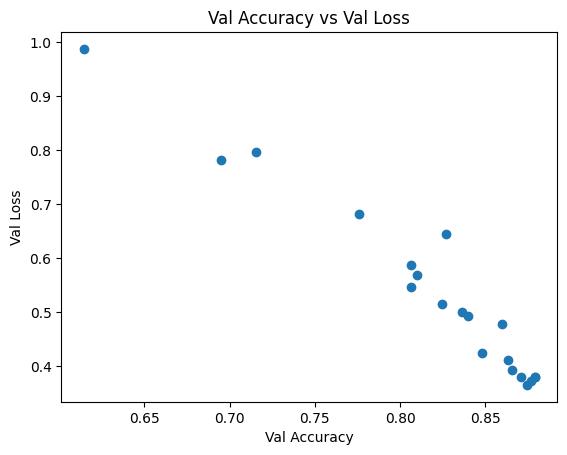

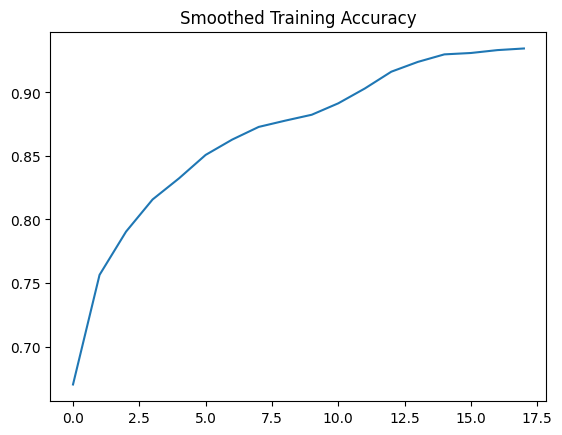

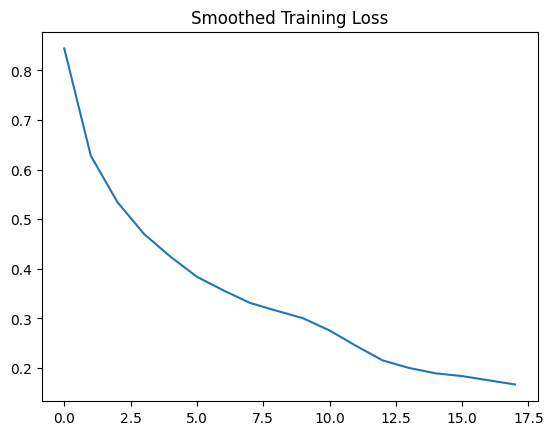

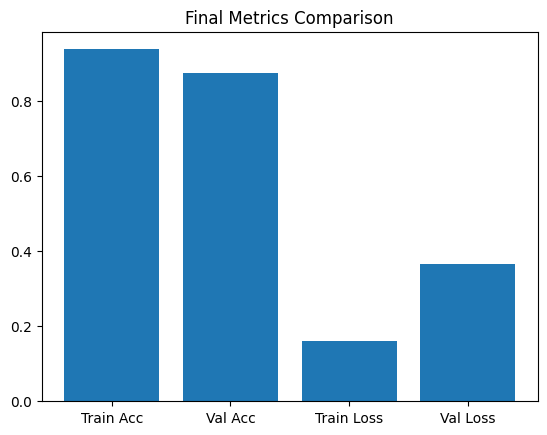

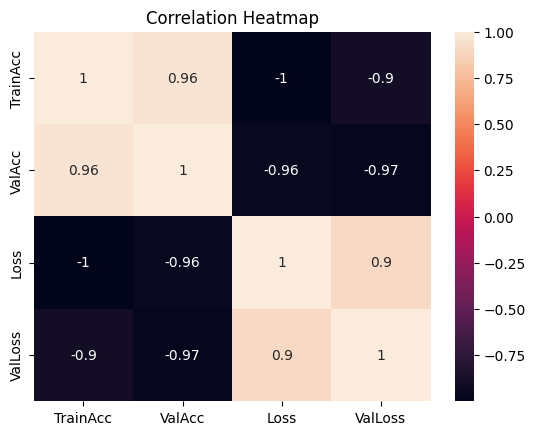

✅ 14 Graphs Generated Successfully!


In [4]:
# ===============================
# ADVANCED VISUALIZATION (10+ GRAPHS)
# ===============================
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# ===============================
# Extract values
# ===============================
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

# ===============================
# GRAPH 1: Accuracy
# ===============================
plt.figure()
plt.plot(epochs, acc, label='Train Accuracy')
plt.plot(epochs, val_acc, label='Val Accuracy')
plt.title("Accuracy vs Epochs")
plt.legend()
plt.grid()
plt.show()

# ===============================
# GRAPH 2: Loss
# ===============================
plt.figure()
plt.plot(epochs, loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Val Loss')
plt.title("Loss vs Epochs")
plt.legend()
plt.grid()
plt.show()

# ===============================
# GRAPH 3: Accuracy Difference
# ===============================
diff = np.array(acc) - np.array(val_acc)
plt.figure()
plt.plot(epochs, diff)
plt.title("Overfitting Gap (Train - Val Accuracy)")
plt.grid()
plt.show()

# ===============================
# GRAPH 4: Loss Difference
# ===============================
loss_diff = np.array(val_loss) - np.array(loss)
plt.figure()
plt.plot(epochs, loss_diff)
plt.title("Loss Gap (Val - Train)")
plt.grid()
plt.show()

# ===============================
# GRAPH 5: Accuracy Histogram
# ===============================
plt.figure()
plt.hist(acc, bins=10)
plt.title("Training Accuracy Distribution")
plt.show()

# ===============================
# GRAPH 6: Validation Accuracy Histogram
# ===============================
plt.figure()
plt.hist(val_acc, bins=10)
plt.title("Validation Accuracy Distribution")
plt.show()

# ===============================
# GRAPH 7: Loss Histogram
# ===============================
plt.figure()
plt.hist(loss, bins=10)
plt.title("Training Loss Distribution")
plt.show()

# ===============================
# GRAPH 8: Validation Loss Histogram
# ===============================
plt.figure()
plt.hist(val_loss, bins=10)
plt.title("Validation Loss Distribution")
plt.show()

# ===============================
# GRAPH 9: Accuracy vs Loss Scatter
# ===============================
plt.figure()
plt.scatter(acc, loss)
plt.title("Train Accuracy vs Loss")
plt.xlabel("Accuracy")
plt.ylabel("Loss")
plt.show()

# ===============================
# GRAPH 10: Val Accuracy vs Val Loss Scatter
# ===============================
plt.figure()
plt.scatter(val_acc, val_loss)
plt.title("Val Accuracy vs Val Loss")
plt.xlabel("Val Accuracy")
plt.ylabel("Val Loss")
plt.show()

# ===============================
# GRAPH 11: Moving Average Accuracy
# ===============================
window = 3
moving_avg = np.convolve(acc, np.ones(window)/window, mode='valid')

plt.figure()
plt.plot(moving_avg)
plt.title("Smoothed Training Accuracy")
plt.show()

# ===============================
# GRAPH 12: Moving Average Loss
# ===============================
moving_loss = np.convolve(loss, np.ones(window)/window, mode='valid')

plt.figure()
plt.plot(moving_loss)
plt.title("Smoothed Training Loss")
plt.show()

# ===============================
# GRAPH 13: Final Metrics Comparison
# ===============================
final_metrics = [acc[-1], val_acc[-1], loss[-1], val_loss[-1]]
labels = ['Train Acc', 'Val Acc', 'Train Loss', 'Val Loss']

plt.figure()
plt.bar(labels, final_metrics)
plt.title("Final Metrics Comparison")
plt.show()

# ===============================
# GRAPH 14: Heatmap (Correlation)
# ===============================
data = np.array([acc, val_acc, loss, val_loss])
corr = np.corrcoef(data)

plt.figure()
sns.heatmap(corr, annot=True,
            xticklabels=['TrainAcc','ValAcc','Loss','ValLoss'],
            yticklabels=['TrainAcc','ValAcc','Loss','ValLoss'])
plt.title("Correlation Heatmap")
plt.show()

print("✅ 14 Graphs Generated Successfully!")

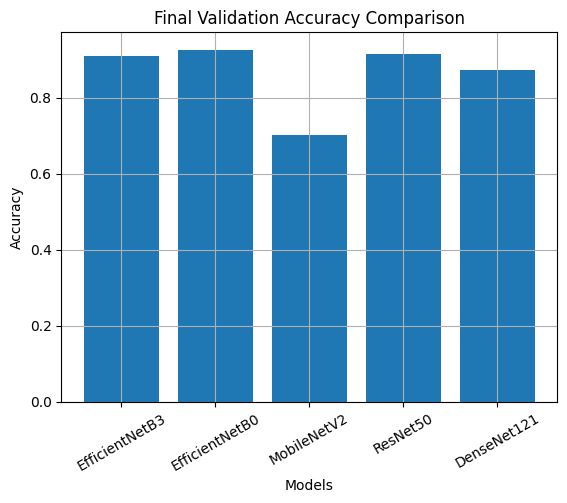

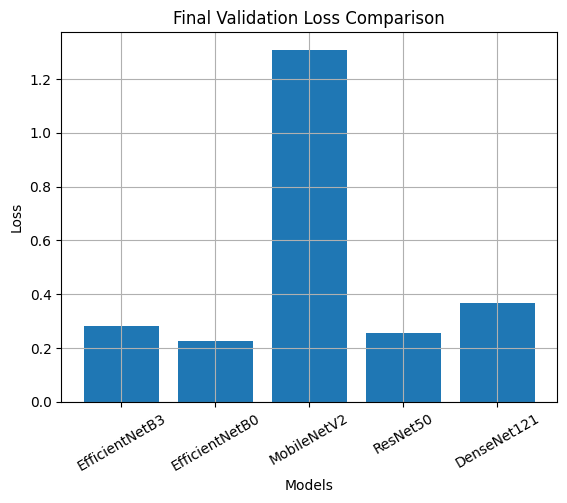

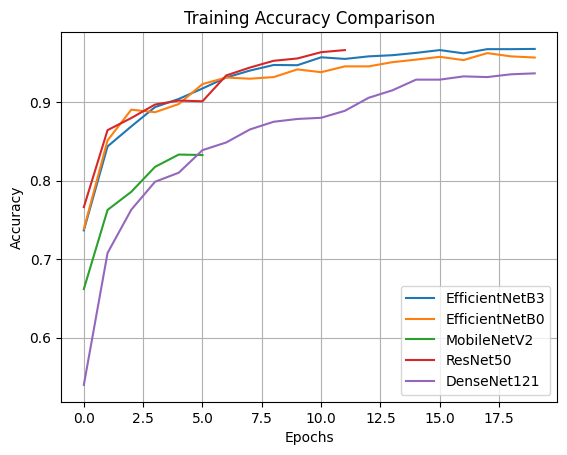

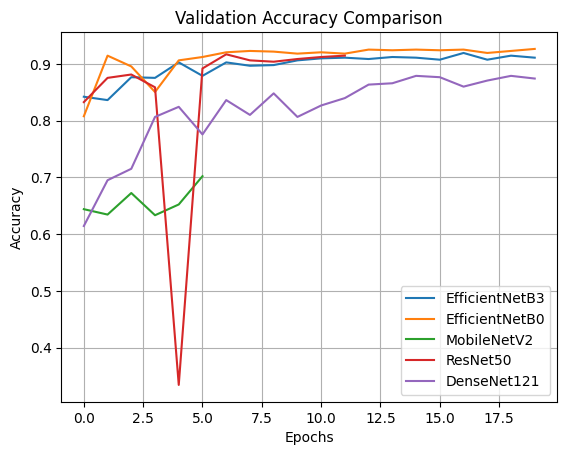

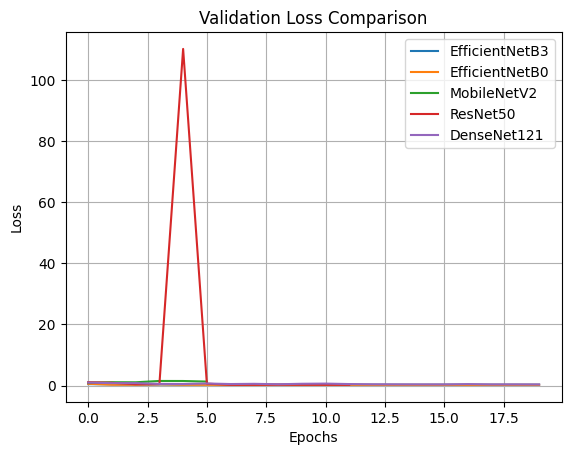

✅ 5 Model Comparison Graphs Generated Successfully!


In [5]:
# ===============================
# MODEL COMPARISON VISUALIZATION
# ===============================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

models = list(history_dict.keys())

# ===============================
# GRAPH 1: FINAL ACCURACY COMPARISON
# ===============================
final_acc = [history_dict[m]['val_accuracy'][-1] for m in models]

plt.figure()
plt.bar(models, final_acc)
plt.title("Final Validation Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.grid()
plt.show()

# ===============================
# GRAPH 2: FINAL LOSS COMPARISON
# ===============================
final_loss = [history_dict[m]['val_loss'][-1] for m in models]

plt.figure()
plt.bar(models, final_loss)
plt.title("Final Validation Loss Comparison")
plt.xlabel("Models")
plt.ylabel("Loss")
plt.xticks(rotation=30)
plt.grid()
plt.show()

# ===============================
# GRAPH 3: TRAINING ACCURACY CURVES
# ===============================
plt.figure()
for m in models:
    plt.plot(history_dict[m]['accuracy'], label=m)
plt.title("Training Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

# ===============================
# GRAPH 4: VALIDATION ACCURACY CURVES
# ===============================
plt.figure()
for m in models:
    plt.plot(history_dict[m]['val_accuracy'], label=m)
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

# ===============================
# GRAPH 5: LOSS CURVES COMPARISON
# ===============================
plt.figure()
for m in models:
    plt.plot(history_dict[m]['val_loss'], label=m)
plt.title("Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

print("✅ 5 Model Comparison Graphs Generated Successfully!")